# Example for parametric method


In [1]:
# %pip install bssunfold

In [2]:
from bssunfold import Detector, RF_LANL
from bssunfold.utils.plotting import plot_comparison

## Load the response functions file for the BSS
- first column: Energy in MeV
- other columns: detector responses for the set of moderator spheres

In [3]:
det = Detector(RF_LANL)

In [4]:
# reference spectrum ISO Cf-252.
reference_spectrum = {
    "E_MeV": [
        1e-09,
        1.5848931924611136e-09,
        2.5118864315095803e-09,
        3.981071705534973e-09,
        6.309573444801934e-09,
        1e-08,
        1.5848931924611143e-08,
        2.511886431509581e-08,
        3.9810717055349736e-08,
        6.309573444801934e-08,
        1.0000000000000001e-07,
        1.5848931924611143e-07,
        2.5118864315095823e-07,
        3.9810717055349735e-07,
        6.309573444801937e-07,
        1.0000000000000002e-06,
        1.584893192461114e-06,
        2.5118864315095823e-06,
        3.981071705534973e-06,
        6.309573444801937e-06,
        1e-05,
        1.584893192461114e-05,
        2.5118864315095822e-05,
        3.9810717055349776e-05,
        6.309573444801943e-05,
        0.0001,
        0.00015848931924611142,
        0.0002511886431509582,
        0.0003981071705534978,
        0.0006309573444801943,
        0.001,
        0.0015848931924611143,
        0.0025118864315095825,
        0.003981071705534978,
        0.006309573444801942,
        0.01,
        0.01584893192461114,
        0.025118864315095826,
        0.039810717055349776,
        0.06309573444801943,
        0.1,
        0.15848931924611173,
        0.25118864315095824,
        0.3981071705534969,
        0.6309573444801944,
        1.0,
        1.5848931924611174,
        2.5118864315095824,
        3.9810717055349856,
        6.309573444801943,
        10.0,
        15.848931924611176,
        25.118864315095824,
        39.810717055349855,
        63.09573444801943,
        100.0,
        158.48931924611173,
        251.18864315095823,
        398.1071705534986,
        630.9573444801944,
    ],
    "Phi": [
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0002193244132568562,
        0.000922,
        0.0017977302145640818,
        0.0033934229230273556,
        0.00638236969883396,
        0.01212580290671056,
        0.0237,
        0.04468185467401807,
        0.0822779218679577,
        0.1450462719353082,
        0.2413649401952857,
        0.359,
        0.45221093414611185,
        0.4338707690763234,
        0.2708850368693928,
        0.0856762250762,
        0.00427,
        0.0004258199483775139,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
    ],
}

## Get effective readings for spectra

In [5]:
readings = det.get_effective_readings_for_spectra(reference_spectrum)

In [6]:
results = {
    "Bayes-param": det.unfold_bayesian_parametric(readings),
    "Bayes-fruit": det.unfold_fruit_like(readings),
    "Hybrid": det.unfold_hybrid_parametric(readings),
    "FRUIT-Param": det.unfold_parametric(readings),
}


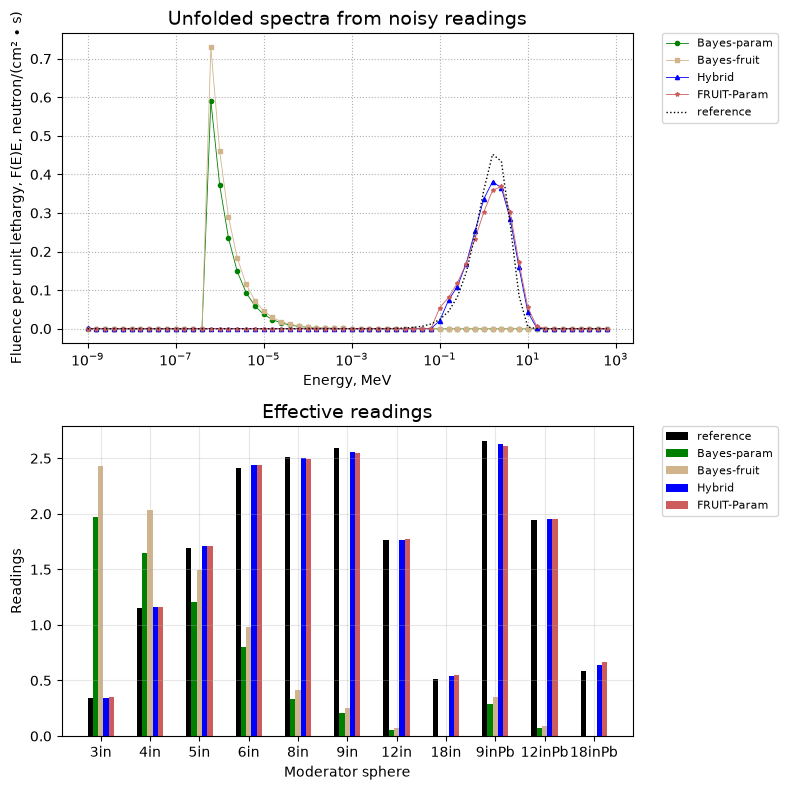

In [7]:
fig, ax = plot_comparison(
    results=results, 
    readings=readings, 
    reference_spectrum=reference_spectrum, 
)

# Comparison

In [8]:
det.compare(reference_spectrum,results['Bayes-param'])

{'kl_divergence': 16.135657222924166,
 'cross_entropy': 18.228966666524094,
 'entropy_difference_percent': 770.820447605454,
 'wasserstein_dist': 0.0140883939347182,
 'energy_dist': 0.028807342672098477,
 'kolmogorov_smirnov_stat': 0.7,
 'pearson_r': -0.1008278479548724,
 'spearman_r': 0.001885234485801351,
 'mean_squared_error': 0.021187327259395584,
 'root_mean_squared_error': 0.14555867291025837,
 'mean_absolute_error': 0.06281731483016255,
 'mape': 98.17077518488004,
 'r2_score': -1.0743803100480926,
 'max_error': 0.5908737984240706,
 'median_absolute_error': 0.0009105951236724878,
 'cosine_similarity': 5.151828535214382e-07,
 'total_flux_ratio': 0.7384244677186907,
 'mmd_rbf': 0.008441159063265369,
 'chi_squared': 19071777.3400733,
 'g_test': 32.27131444584833,
 'freeman_tukey': 7.991793042678438,
 'cressie_read': 116566.88156707474,
 'anderson_darling': 38.07215099051486,
 'standardized_mean_difference': 0.09574522310430122,
 'wilcoxon_test': 788.0,
 'mannwhitneyu_test': 941.0,
 

# Paramentric with QP

solver_backend format: "cvxpy", "cvxpy:ECOS", "qpsolvers", "qpsolvers:osqp", or "auto".

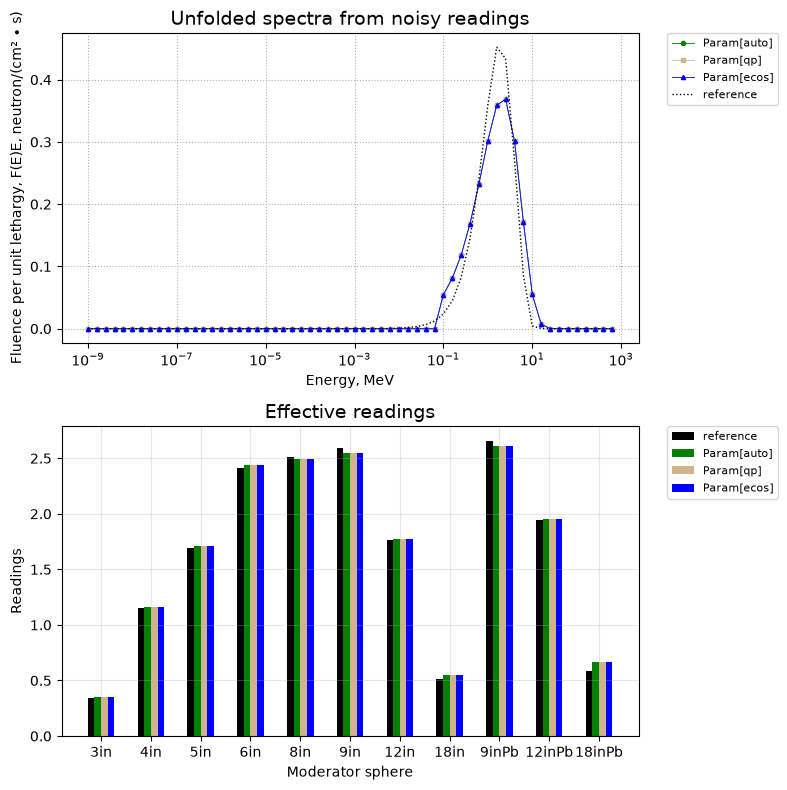

{'kl_divergence': 0.3818606739082002,
 'cross_entropy': 2.475170117508124,
 'entropy_difference_percent': 18.241960120884173,
 'wasserstein_dist': 0.00871231060928864,
 'energy_dist': 0.022261341779487034,
 'kolmogorov_smirnov_stat': 0.7,
 'pearson_r': 0.9764157729030448,
 'spearman_r': 0.4095414842973554,
 'mean_squared_error': 0.0005269287669955523,
 'root_mean_squared_error': 0.02295492903486204,
 'mean_absolute_error': 0.009181767984143588,
 'mape': 211.3936172162593,
 'r2_score': 0.9484101677539919,
 'max_error': 0.09344756779636965,
 'median_absolute_error': 3.507202637642702e-07,
 'cosine_similarity': 0.9785851162929893,
 'total_flux_ratio': 1.0243351106728869,
 'mmd_rbf': 0.020008973910669248,
 'chi_squared': 95698061521.98058,
 'g_test': 0.7637213478164004,
 'freeman_tukey': 0.18180543205885763,
 'cressie_read': 8133412.613909757,
 'anderson_darling': 38.116296406093085,
 'standardized_mean_difference': -0.009041502982567307,
 'wilcoxon_test': 499.0,
 'mannwhitneyu_test': 931.

In [9]:
results_qp = {
    "Param[auto]": det.unfold_parametric(readings),
    "Param[qp]": det.unfold_parametric(readings,solver_backend ="qpsolvers"),
    "Param[ecos]": det.unfold_parametric(readings, solver_backend ="cvxpy:ECOS"),
}

fig, ax = plot_comparison(
    results=results_qp, 
    readings=readings, 
    reference_spectrum=reference_spectrum, 
)

det.compare(reference_spectrum,results_qp['Param[auto]'])

# Parametric2 (BON-95)

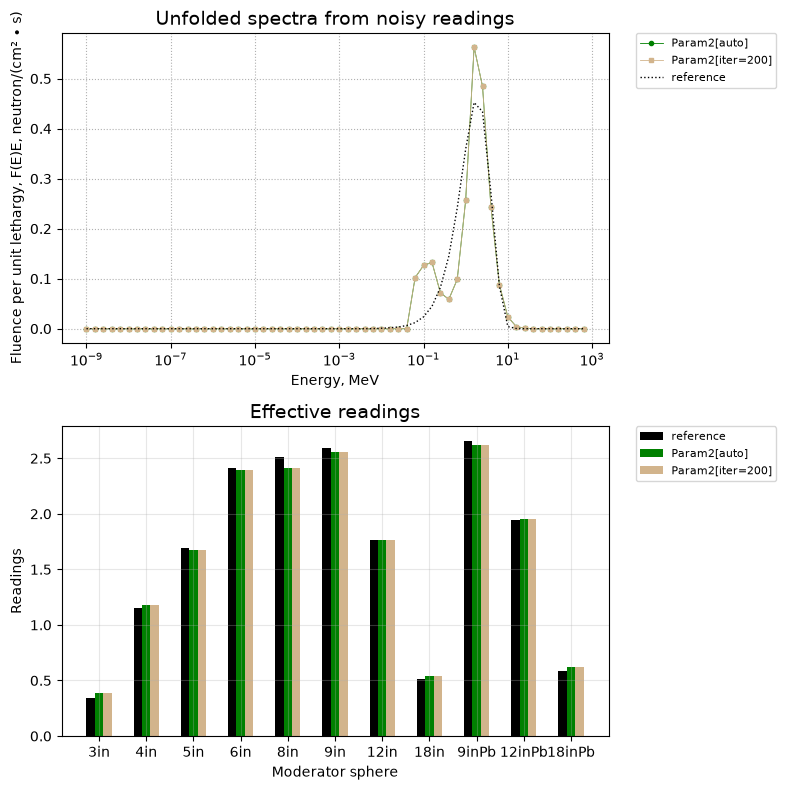

{'kl_divergence': 0.2584581006525158,
 'cross_entropy': 2.3517675442524384,
 'entropy_difference_percent': 12.346865459510713,
 'wasserstein_dist': 0.010201220041710887,
 'energy_dist': 0.02301715519065099,
 'kolmogorov_smirnov_stat': 0.6833333333333333,
 'pearson_r': 0.9374267921314594,
 'spearman_r': 0.5048657952976019,
 'mean_squared_error': 0.0013474347866066605,
 'root_mean_squared_error': 0.03670742141048129,
 'mean_absolute_error': 0.014197604493111561,
 'mape': 192.34205487672128,
 'r2_score': 0.8680771691402832,
 'max_error': 0.14282700334187326,
 'median_absolute_error': 2.3680880246014598e-05,
 'cosine_similarity': 0.9445238594973523,
 'total_flux_ratio': 1.0404010390689125,
 'mmd_rbf': 0.019545370883197632,
 'chi_squared': 7329937765.826674,
 'g_test': 0.5169162013050316,
 'freeman_tukey': 0.36042035789883536,
 'cressie_read': 935927.4207749246,
 'anderson_darling': 36.358978842707366,
 'standardized_mean_difference': -0.014043130789220202,
 'wilcoxon_test': 489.0,
 'mannwh

In [10]:
results_qp2 = {
    "Param2[auto]": det.unfold_parametric2(readings),
    "Param2[iter=200]": det.unfold_parametric2(readings,max_iter =200),
}

fig, ax = plot_comparison(
    results=results_qp2, 
    readings=readings, 
    reference_spectrum=reference_spectrum, 
)

det.compare(reference_spectrum,results_qp2['Param2[auto]'])